## 3. YOLO目标分割
### 3.1 获取图像数据并加载分割模型

In [7]:
import cv2
from sensor_msgs.msg import Image
from cv_bridge import CvBridge, CvBridgeError
import numpy as np
from reirobot_API import DynamicTFPublisher
from ultralytics import YOLO

model = YOLO("./weights/best.pt")
rei_tf = DynamicTFPublisher()
rei_tf.clear_all_tf()


[INFO] [1781948094.582658, 634.565000]: TF发布子线程已启动
[INFO] [1781948094.584953, 634.567000]: 🧹 已清空所有动态TF


True

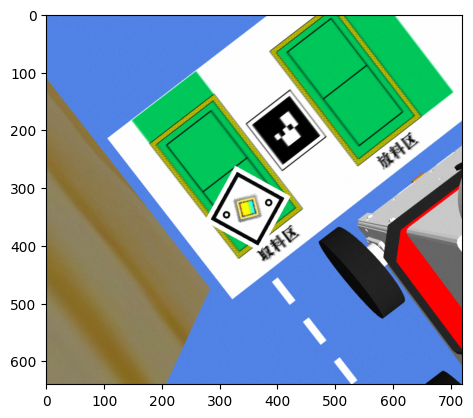

In [8]:
import matplotlib.pyplot as plt

bridge = CvBridge()
image_msg = rospy.wait_for_message("/hand_camera/image_raw",Image)
cv_image = bridge.imgmsg_to_cv2(image_msg, desired_encoding="bgr8")
plt.imshow(cv_image[:,:,::-1])
plt.show()

### 3.1 识别图像

In [9]:
results = model(cv_image, show=False, save=True)


0: 576x640 1 chips, 222.7ms
Speed: 8.2ms preprocess, 222.7ms inference, 9.8ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /home/reicom2025/reinovo_visual_tutorial/runs/segment/predict


### 3.2 获取分割结果
![image](../runs/segment/predict/image0.jpg)

### 3.3 获取识别到标签

In [10]:
names = [result.names for result in results]
print(names)

[{0: 'chips', 1: 'lens', 2: 'camera', 3: 'pcb', 4: 'rotor', 5: 'servo'}]


### 3.4 获取分割后的掩码图

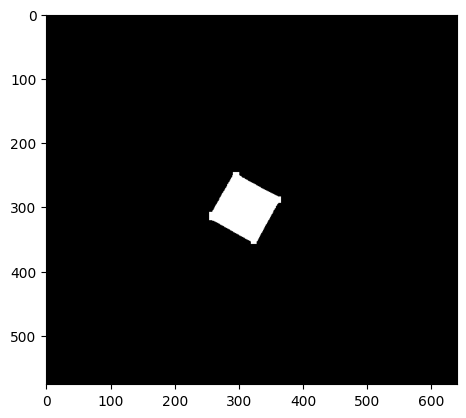

In [11]:
mask = results[0].masks.data[0].cpu().numpy().squeeze()
plt.imshow(mask,cmap="gray")
plt.show()

## 4. 获取角点（轮廓处理）
### 4.1 轮廓提取

(-0.5, 639.5, 575.5, -0.5)

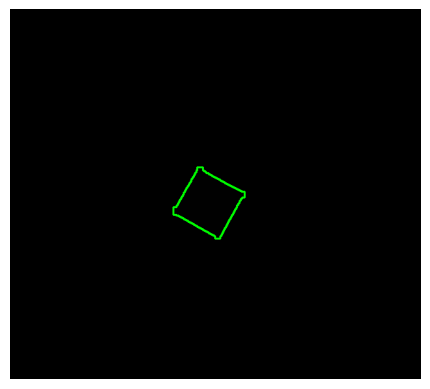

In [12]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)

img_contour = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_contour, [cnt], -1, (0,255,0), 2)

plt.imshow(img_contour)
plt.axis("off")

## 4.1 多边形逼近获取轮廓角点

(-0.5, 719.5, 639.5, -0.5)

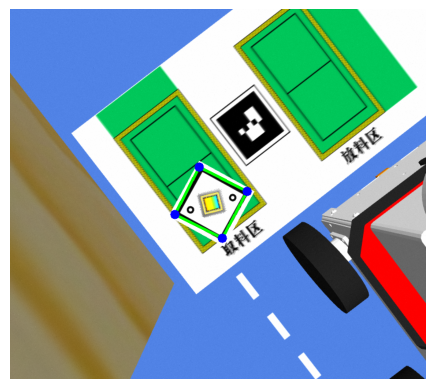

In [13]:
epsilon = 0.02 * cv2.arcLength(cnt, True)
approx = cv2.approxPolyDP(cnt, epsilon, True)

# 坐标缩放回原图
h0, w0 = results[0].orig_shape                  # 原图高、宽
h_in, w_in = results[0].masks.shape[1:]         # mask 尺寸 (h, w)
scale_x = w0 / w_in                          # x 缩放比例
scale_y = h0 / h_in                          # y 缩放比例

# 把 mask 上的角点 → 映射到原图坐标
approx_original = (approx * [scale_x, scale_y]).astype(np.int32)

img_approx = np.copy(cv_image)
cv2.drawContours(img_approx, [approx_original], -1, (0, 255, 0), 3)  # 绿色轮廓

for p in approx_original:
    cx, cy = p[0]
    cv2.circle(img_approx, (cx, cy), 8, (255, 0, 0), -1)  # 蓝色角点

plt.imshow(img_approx[..., ::-1])
plt.axis("off")

## 5. pnp 求解
PnP（Perspective-n-Point）：透视 n 点问题，已知世界坐标系下 n 个 3D 点坐标、图像坐标系下对应 2D 像素坐标、相机内参，求解相机外参（旋转矩阵 R + 平移向量 t），即相机在世界坐标系下的位姿。


In [14]:
# 整理 2D 角点
image_points = np.array([
    approx_original[0][0], approx_original[1][0], approx_original[2][0], approx_original[3][0]
], dtype=np.float32)

# 定义 3D 角点
square_size = 0.03
object_points = np.array([
    [-square_size/2,  square_size/2, 0],
    [ square_size/2,  square_size/2, 0],
    [ square_size/2, -square_size/2, 0],
    [-square_size/2, -square_size/2, 0],
], dtype=np.float64)

### 5.1 获取相机内参

In [15]:
from sensor_msgs.msg import CameraInfo 
# 相机内参
camera_info = rospy.wait_for_message('hand_camera/camera_info',CameraInfo)
camera_matrix = np.array(camera_info.K,np.float64).reshape(3,3)
dist_coeffs = np.array(camera_info.D, np.float64)

### 5.2 pnp求解获取平移和旋转矩阵

In [16]:
ret, rvec, tvec = cv2.solvePnP(object_points, image_points, camera_matrix, dist_coeffs)
R, _ = cv2.Rodrigues(rvec)
print("旋转矩阵 R:\n", np.round(R, 3))
print("平移 T (m):", np.round(tvec.flatten(), 3))

旋转矩阵 R:
 [[     -0.458      -0.888      -0.021]
 [      0.885      -0.454      -0.101]
 [      0.081      -0.065       0.995]]
平移 T (m): [     -0.004       0.005       0.139]


### 5.3 将旋转矩阵转为四元素

In [17]:
from tf.transformations import quaternion_from_matrix
T = np.eye(4)
T[:3,:3] = R
q = quaternion_from_matrix(T)
print("四元素为：",q)

四元素为： [   0.017487   -0.048757     0.85254     0.52009]


### 5.4 发布目标tf
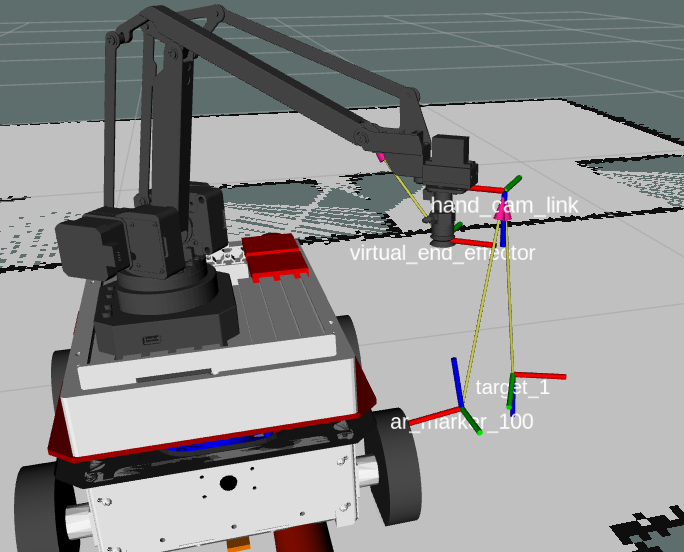

In [18]:
rei_tf.clear_all_tf()
rei_tf.add_dynamic_tf('hand_cam_link','target_1',tvec.ravel(),q)

[INFO] [1781948186.858034, 724.558000]: 🧹 已清空所有动态TF
[INFO] [1781948186.860749, 724.561000]: ✅ 已添加TF：hand_cam_link → target_1


True

### 5.5 移动到目标位置

arm.arm_move([200,-150,120])
rospy.sleep(1)
pos,rot = base.get_tf("Base","target_1")
pos = [p*1000 for p in pos]
arm.arm_move(pos)

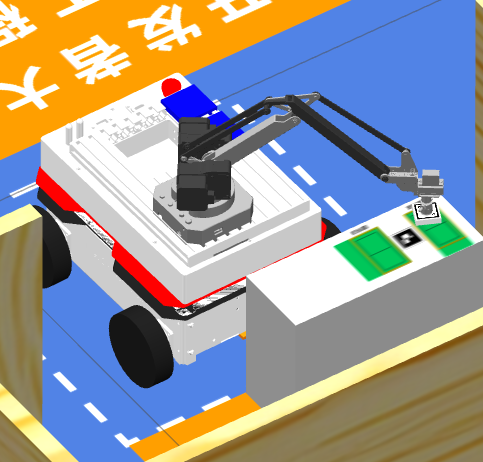